1. total parameters=10*784+10=7850

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import torch.utils.data as data


torch.manual_seed(1337)
np.random.seed(1337)
random.seed(1337)

In [52]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [53]:
def preprocess_data(dataset):
    data = (dataset.data / 255.0) - 0.5
    flattened_data = data.view(data.shape[0], -1)
    targets = dataset.targets
    return flattened_data, targets

x_train, y_train = preprocess_data(trainset)
x_test, y_test = preprocess_data(testset)

In [54]:
class MNISTNetworkLinear(nn.Module):
    def __init__(self):
        super().__init__()
        # Single linear layer: 784 -> 10
        self.layer = nn.Linear(in_features=784, out_features=10)
    
    def forward(self, x):
        # Return logits (CrossEntropyLoss will apply softmax)
        logits = self.layer(x)
        return logits

In [55]:
model=MNISTNetworkLinear()

loss_function=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.2)

train_dataset = data.TensorDataset(x_train, y_train)

batch_size = 1024
epochs = 10
train_loader = data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


In [60]:
results={}
init_name=['default', 'zeros', 'small', 'large']
for i in range(4):
    print(f"\n{init_name[i]} initialization:")
    
    # Create new model with specific initialization
    if i==0:
        test_model=MNISTNetworkLinear()
    elif i==1:
        test_model=MNISTNetworkLinear()
        nn.init.zeros_(test_model.layer.weight)
        nn.init.zeros_(test_model.layer.bias)
    elif i==2:
        test_model = MNISTNetworkLinear()
        nn.init.normal_(test_model.layer.weight, mean=0, std=0.01)
        nn.init.zeros_(test_model.layer.bias)
    else:
        test_model=MNISTNetworkLinear()
        nn.init.normal_(test_model.layer.weight, mean=0, std=1.0)
        nn.init.zeros_(test_model.layer.bias)
    
    test_optimizer=optim.SGD(test_model.parameters(), lr=0.2)
    
    for epoch in range(5):
        test_model.train()
        for x_batch, y_batch in train_loader:
            logits = test_model(x_batch)
            loss = loss_function(logits, y_batch)
            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()
    
    test_model.eval()
    with torch.no_grad():
        logits = test_model(x_test)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y_test).float().mean().item() * 100
    
    results[init_name[i]] = acc
    print(f"  Final Accuracy: {acc:.2f}%")



default initialization:
  Final Accuracy: 90.21%

zeros initialization:
  Final Accuracy: 90.35%

small initialization:
  Final Accuracy: 90.27%

large initialization:
  Final Accuracy: 77.59%


There's a significant accuracy drop in large initialization. Possibly learning rate and weight are too large, causing each step to shift much significantly and optimization to be unstable. 

In [56]:
train_losses=[]
test_losses=[]
train_accs=[]
test_accs=[]

for epoch in range(epochs):
    model.train()
    total_loss=0
    correct_train=0
    total_train=0
    for x_batch, y_batch in train_loader:
        logits = model(x_batch)
        loss = loss_function(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _,predicted=torch.max(logits,1)
        total_train+=y_batch.size(0)
        correct_train+=(predicted==y_batch).sum().item()

    avg_loss = total_loss / len(train_loader) # The number of batches is len(train_loader)
    train_acc=100*correct_train/total_train
    train_losses.append(avg_loss)
    train_accs.append(train_acc)

    model.eval()
    with torch.no_grad():
        logits = model(x_test)
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        test_loss=loss_function(logits,y_test)
        predicted_classes=torch.argmax(probabilities,dim=1)
        test_acc=(predicted_classes==y_test).float().mean().item()*100

    test_losses.append(test_loss.item())
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}"
          f"Train Loss: {avg_loss:.4f} Train Accuracy: {train_acc:.2f}%"
          f"Test Loss: {test_loss.item():.4f} Test Accuracy: {test_acc:.2f}%")

print(f"min train loss: {min(train_losses):.4f}")



Epoch 1Train Loss: 0.9925 Train Accuracy: 71.05%Test Loss: 0.5687 Test Accuracy: 85.22%
Epoch 2Train Loss: 0.5054 Train Accuracy: 86.91%Test Loss: 0.4412 Test Accuracy: 88.39%
Epoch 3Train Loss: 0.4371 Train Accuracy: 88.35%Test Loss: 0.3945 Test Accuracy: 89.33%
Epoch 4Train Loss: 0.4049 Train Accuracy: 89.00%Test Loss: 0.3762 Test Accuracy: 89.79%
Epoch 5Train Loss: 0.3848 Train Accuracy: 89.42%Test Loss: 0.3592 Test Accuracy: 90.17%
Epoch 6Train Loss: 0.3710 Train Accuracy: 89.66%Test Loss: 0.3504 Test Accuracy: 90.15%
Epoch 7Train Loss: 0.3598 Train Accuracy: 89.94%Test Loss: 0.3412 Test Accuracy: 90.58%
Epoch 8Train Loss: 0.3519 Train Accuracy: 90.22%Test Loss: 0.3311 Test Accuracy: 90.93%
Epoch 9Train Loss: 0.3445 Train Accuracy: 90.33%Test Loss: 0.3251 Test Accuracy: 90.98%
Epoch 10Train Loss: 0.3389 Train Accuracy: 90.45%Test Loss: 0.3206 Test Accuracy: 91.03%
min train loss: 0.3389


In [57]:
model.eval()

with torch.no_grad():
    logits = model(x_test)
    probabilities = torch.nn.functional.softmax(logits, dim=1)

predicted_classes = torch.argmax(probabilities, dim=1)

accuracy = (predicted_classes == y_test).float().mean()

print(f"Overall Accuracy: {accuracy.item() * 100:.2f}%")

confusion_matrix = np.zeros((10, 10), dtype=np.int32)

for i in range(len(x_test)):
    actual_class = y_test[i].item()
    predicted_class = predicted_classes[i].item()

    confusion_matrix[actual_class, predicted_class] += 1

print("Confusion Matrix")
print(confusion_matrix)

Overall Accuracy: 91.03%
Confusion Matrix
[[ 954    0    2    2    0    8   10    1    3    0]
 [   0 1106    2    3    0    2    4    2   16    0]
 [  12   12  894   15   19    2   14   19   35   10]
 [   4    2   17  916    1   26    2   15   14   13]
 [   1    4    3    1  922    1   11    1    5   33]
 [   8    5    2   47   14  755   18   11   24    8]
 [  11    3    5    2   15   14  905    1    2    0]
 [   2   17   21    5   10    0    0  934    3   36]
 [   7   12   10   30   11   32   12   14  832   14]
 [  11    7    5   11   53    7    0   22    8  885]]


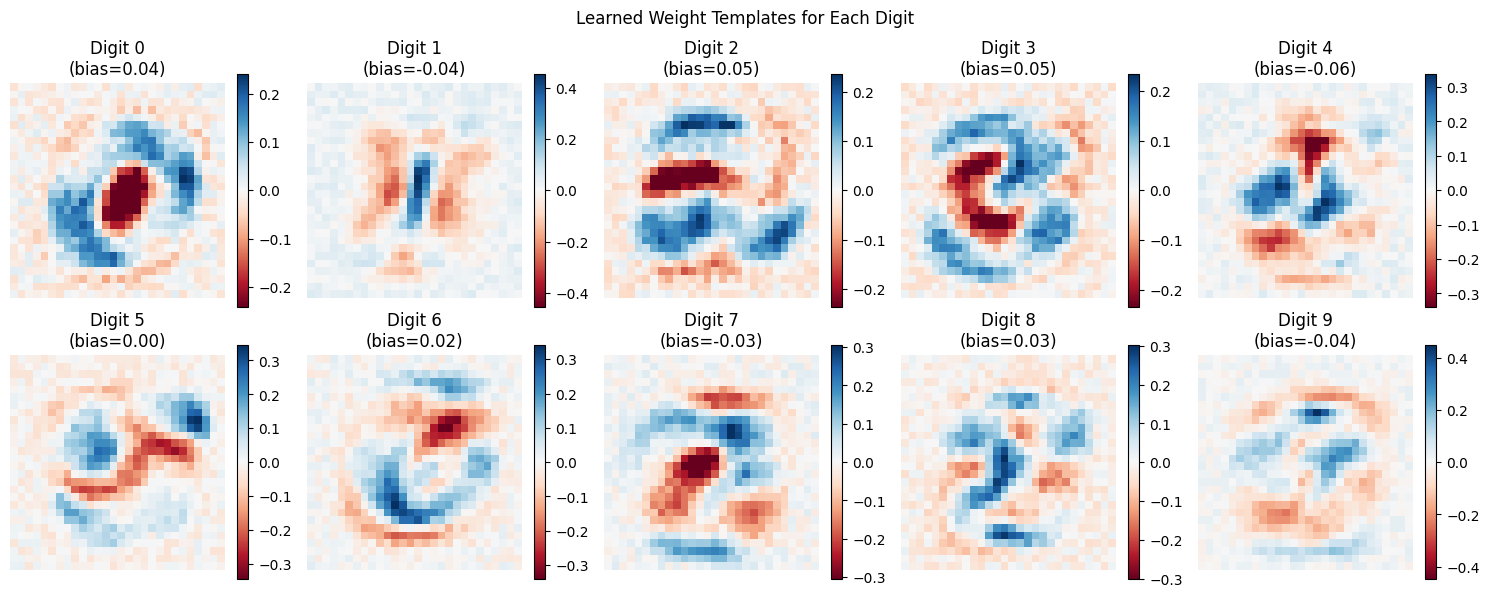

In [58]:
fig,axes=plt.subplots(2, 5, figsize=(15, 6))
axes=axes.flatten()

weight_matrix=model.layer.weight.data
bias_vector=model.layer.bias.data

for i in range(10):
    weight=weight_matrix[i]
    weight=weight.cpu()
    weight=weight.detach()
    
    weight_image=weight.reshape(28, 28)
    try:
        weight_np=weight_image.numpy()
    except:
        try:
            weight_np=weight_image.clone().numpy()
        except:
            weight_np=np.array(weight_image.tolist())
    
    ax=axes[i]
    im=ax.imshow(weight_np, cmap='RdBu', 
                   vmin=-weight_np.max(), vmax=weight_np.max())
    ax.set_title(f'Digit {i}\n(bias={bias_vector[i].item():.2f})')
    ax.axis('off')
    plt.colorbar(im,ax=ax,fraction=0.05)

plt.suptitle('Learned Weight Templates for Each Digit')
plt.tight_layout()
plt.show()

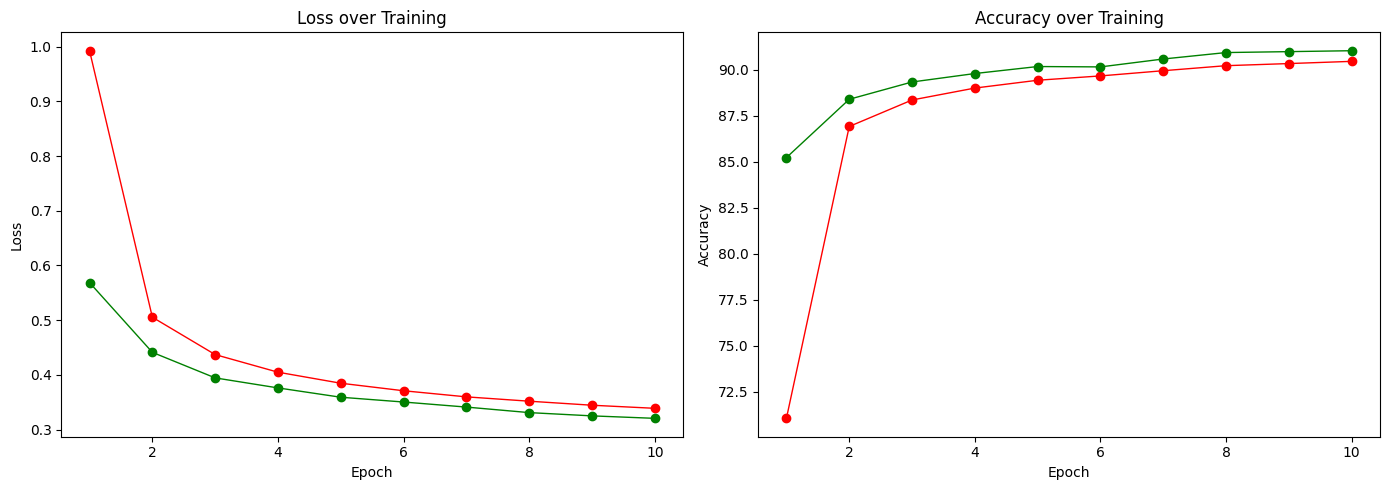

In [59]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(range(1, epochs+1), train_losses, 'r-o', label='Train Loss', linewidth=1)
ax1.plot(range(1, epochs+1), test_losses, 'g-o', label='Test Loss', linewidth=1)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Training')

ax2.plot(range(1, epochs+1), train_accs, 'r-o', label='Train Accuracy', linewidth=1)
ax2.plot(range(1, epochs+1), test_accs, 'g-o', label='Test Accuracy', linewidth=1)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over Training')

plt.tight_layout()
plt.show()

I chose a learning rate of 0.2, optimizer SGD and batch size of 1024 as for an ordinary computer, and Epochs 10 when improvements hardly improves further than it. Eventually I reached train loss of .3389, train accuracy of .9045 test loss of .3206, test accuracy of .9103. Training stopped when loss change is smaller than 0.01 i.e. converging. 